# **Detector de Conflitos em Textos - PGC UFABC**

Espaço para desenvolvimento, teste e implementação do modelo de detecção de conflitos em textos, proposto no Projeto de Graduação em Computação da Universidade Federal do ABC



**Orientandos:**

*   Caio Cardoso dos Santos
*   Victor Ravazio de Lima

**Orientador:**

*   Prof. Dr. Carlos da Silva dos Santos




# **Conceitos e direções**

## **Conceiros essenciais - Super Resumo**



*   BERT - Modelo de Linguagem baseado em Transformers - Aprende relações semanticas profundas em textos

*   BERTimbau - BERT pré-treinado em portugês Br

*   Tokenizer - converte texto em numeros (IDS), onde cada inteiro é um indice no vocabulo.

  EX: "Eu adorei esse produto" => input_ids = [101, 1198, 17842, 1239, 15323, 102].
  
  Basicamento o Bert possui um dicionario estático e cada valor desse vetor de input corresponde a posição em que determinada palavra ou prefixo está localizada neste dicionario.


*   Fine-tuning - Ajustar o modelo para a tarefa especifica
*   Modelo: [neuralmind/bert-base-portuguese-cased](https://https://huggingface.co/neuralmind/bert-base-portuguese-cased)

**Fonte:** @inproceedings{souza2020bertimbau,
  author    = {F{\'a}bio Souza and
               Rodrigo Nogueira and
               Roberto Lotufo},
  title     = {{BERT}imbau: pretrained {BERT} models for {B}razilian {P}ortuguese},
  booktitle = {9th Brazilian Conference on Intelligent Systems, {BRACIS}, Rio Grande do Sul, Brazil, October 20-23 (to appear)},
  year      = {2020}
}

Fontes auxiliares e projetos:

Fonte 2: https://arthuremanuel-carosia.medium.com/usando-o-bert-para-an%C3%A1lise-de-sentimentos-363f76eee15e

Fonte 3: https://gist.github.com/Hugobsan/b507b76c7b5fc470d77b3a924211430d#file-pr-processamento-ipynb




##**Pipeline idealizado (provisório?)**


Dado o Dataset com Tweets:

*   Cada Dataset temático é divido em 3 subestruturas: Tweets genéricos, repys e quotes


  
*   Gera-se pares de tweets dentro de uma mesma subestrutura: Reply com seu respectivo replied tweet; Quote com seu respsctivo Quoted tweet; e original pareado com outro tweet origginal de forma aleatoria (amostragem aleatoria)

*   Para cada par de frases de cada grupo, constrói um dataset com essas informações: frase_1 - frase_2 - Classe - conflito (0/1)
*   Esta tabela seria o dataset de entrada para o bert - Este então aprende os padrões textuais que geralmente associam conflitos - “Que tipo de relação semântica entre frase_1 e frase_2 gera um situação de conflito 1?” -  Ex: bom x ruim; ótimo x péssimo

*   O modelo no fim é necessário pois ele aprende uma fronteira suave e não discreta.






# **Preparação do ambiente**


## **Validando GPU**

In [ ]:
!nvidia-smi #verificando se o ambiente está configurado para GPU


Wed Jun 10 13:19:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **Instalando bibliotecas**

**Sobre as bibliotecas:**


*   Transformers (coleção de modelos pré-treinados em Transformers)
*   datasets (fornece alguns datasets otimizados prontos)
*   accelerate (gerencia multi gpu/otimiza treino em gpu)
*   evaluate (biblioteca de metricas padronizadas)

*   PyTorch (framework de deep learning)

* As 4 primeiras pertencem ao Hugging Face, espécie de "GitHub" de modelos IA







In [ ]:
#Instalando:
!pip install -q transformers datasets torch accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00


In [ ]:
#!pip install torchcodec

In [ ]:
!pip install --upgrade datasets transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.4 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.10.1
    Uninstalling transformers-5.10.1:
      Successfully uninstalled transformers-5.10.1


In [ ]:
#!pip install torchvision==0.21.0 #caso ocorra erro no treinamento, necessario instalar versão anaterior do torchvision

In [ ]:
# modulo para importar dataset a partir de um link
!pip install gdown

# **Importações**

## **Importando Bibliotecas**

**Sobre as bibliotecas:**

*  Torch (Framework para aplicações de machine learn: abstrai tarefas, operacionaliza manipulação de tensores e etc)

*  BertTokenizer(Tokenizar textos)
*   BertModel (Bert puro)
*   BertForSequenceClassification (BERT + Camada de classificador)
*   Trainer (modulo para treino)

*   TrainigArguments (modulo para treino)

*   Gdown (baixar arquivos direto do drive)

* Dataset (otimiza e facilita a formatação do datataset para treino no Bert)

* sklearn (biblioteca que fornece ferramentas prontas para realizar tarefas de ML, como por exemplo "train_test_split" que divide automaticamente treino e teste, ou as metricas de avaliação que abstrai os calculos de precisão, recall e etc)






In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gdown
from google.colab import files


from transformers import (
    BertTokenizer,
    BertModel,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



## **Importando o Modelo**

In [ ]:
#Tokenizer
tokenizer = BertTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")

#Modelo: BERT + Camada de classificação
#num_labels corresponde ao numero de classes do modelo (Conflito/não conflito)
model = BertForSequenceClassification.from_pretrained("neuralmind/bert-base-portuguese-cased", num_labels = 2, problem_type="single_label_classification")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

## **Importando o dataset**

In [ ]:
# baixando dataset para o collab
file_id = "1Op1OxN9N1Ul82YHIiarb3kIq1FSbCdcx"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "dataset_conflitos.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Op1OxN9N1Ul82YHIiarb3kIq1FSbCdcx
To: /content/dataset_conflitos.csv

100%|██████████| 386k/386k [00:00<00:00, 5.81MB/s]


'dataset_conflitos.csv'

In [ ]:
#carregando o dataset
df = pd.read_csv ("dataset_conflitos.csv")
df['Conflict'] = df['Conflict'].astype(int) #convertendo valores para inteiros
df = df[df['Conflict'] != -1] #eliminando indeterminados
df.shape

(1345, 4)

In [ ]:
#Verificando distribuição das classes
conflitos = df[df["Conflict"] == 1].shape[0]
nao_conflitos = df[df["Conflict"] == 0].shape[0]
print("Quantidade de anotações por classes:")
print("0 - Não Conflitos: ", nao_conflitos)
print("1 - Conflitos: ", conflitos)
print(f"Desbalanceamento: {(max(nao_conflitos, conflitos) / min(nao_conflitos, conflitos)):.3f} : 1")

Quantidade de anotações por classes:
0 - Não Conflitos:  1066
1 - Conflitos:  279
Desbalanceamento: 3.821 : 1


In [ ]:
#embaralhando o dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df

,tweet_1,tweet_2,Class,Conflict
0,China critica decisão de Trump e pede volta do...,#AbortoNao Parabéns por não financiar a Chin...,2,0
1,Vamos começar a pressão ao STF já. #AbortoNAO,Fala pra mim .... Mais essa #AbortoNao,1,0
2,Sílvio Santos também indica nome a Bolsonaro p...,Liminha,2,0
3,Como vc se sentiria se tivesse sido abortada? ...,"Agradeceria, isso sim se você é contra o abor...",1,1
4,"O que a Bíblia fala sobre o aborto? ""Antes qu...",Pela vida. #AbortoNAO,1,0
...,...,...,...,...
1340,Mandetta: “Bolsonaro está vendo muito o aspect...,Mandetta faz parte do grupo de beneficiados pe...,1,0
1341,"Para a Globo, que só tinha como alternativa ao...",e o mandetta ontem dizendo que paulo guedes e ...,1,0
1342,"Não desmereço o trabalho do Min. Mandetta, mas...",Quem precisa do Mandetta hj? Maia. Doria. Caia...,2,0
1343,É hora de falar sério. Hoje é um dia de vitór...,Ah velho não dá não dá não dá Tu pode n concor...,2,1


## **Balanceamento provisorio para testes**

In [ ]:
# #----------------Equilibrando dados---------------------------
# df_conflitos = df[df["Conflict"] == 1]
# df_nao_conflitos = df[df["Conflict"] == 0]
# df_nao_conflitos = df_nao_conflitos.sample(n=df_conflitos.shape[0]*2, random_state=42)

# df = pd.concat([df_conflitos, df_nao_conflitos])

In [ ]:
#Verificando novas distribuições das classes
conflitos = df[df["Conflict"] == 1].shape[0]
nao_conflitos = df[df["Conflict"] == 0].shape[0]
print("Quantidade de anotações por classes:")
print("0 - Não Conflitos: ", nao_conflitos)
print("1 - Conflitos: ", conflitos)
print(f"Desbalanceamento: {(max(nao_conflitos, conflitos) / min(nao_conflitos, conflitos)):.3f} : 1")

Quantidade de anotações por classes:
0 - Não Conflitos:  1066
1 - Conflitos:  279
Desbalanceamento: 3.821 : 1


# **Modelo - Conflict Detector**

## **Separando treino e teste**

In [ ]:
#Separando dados em treino e teste
# train_test_split é um método da biblioteca sklearn que abstrai a divisão de treino e test
# O parametro stratify mantém a proporção das classes - Originalmente 80% não conflito e 20% não conflito, assim também será em train e test.
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Conflict"])

#convertendo para o formato "datasets" do Hugging face - Abstrai alguns procedimentos, como formatar para tensores e etc
train_dataset = Dataset.from_pandas(train_df, preserve_index=False) #index = false - não inclui os indices do df original
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

print("Treino:", len(train_dataset))
print("Teste:", len(test_dataset))


Treino: 1076
Teste: 269


In [ ]:
train_dataset

Dataset({
    features: ['tweet_1', 'tweet_2', 'Class', 'Conflict'],
    num_rows: 1076
})

## **Tokenização**

1 - Tokenização consiste em transformar o texto bruto em uma representação numérica estruturada que o modelo BERT consiga processar. Para isso, o texto é dividido em subpalavras (subword tokenization), e cada token é convertido em um identificador numérico correspondente ao índice no vocabulário aprendido pelo modelo.

O processo de tokenização gera três principais componentes:

- input_ids: sequência de identificadores numéricos dos tokens.
- token_type_ids: indica a qual sentença cada token pertence (no caso de pares de sentenças).
- attention_mask: indica quais posições são tokens reais (1) e quais são padding (0).

Na abordagem adotada neste trabalho, a tokenização é feita em pares de tweets, explorando a arquitetura do BERT, que permite modelar relações entre duas sentenças simultaneamente. Dessa forma, o modelo aprende interações semânticas entre os dois textos, em vez de processá-los isoladamente.

A entrada do BERT segue o formato:

[CLS] texto_1 [SEP] texto_2 [SEP]

Para construir essa entrada, utiliza-se o tokenizer do BERT, passando ambos os textos como parâmetros, além de argumentos de controle como padding (para padronizar o tamanho das sequências) e truncation (para limitar o tamanho máximo).

Esses vetores tokenizados são então utilizados como entrada do modelo, que gera embeddings contextualizados para cada token.

Observação: o padding é necessário para garantir que todas as sequências de um batch tenham o mesmo tamanho, já que o processamento é realizado em lotes (batches). Isso é essencial para a eficiência computacional e compatibilidade com o formato esperado pelo modelo.

2 - Este processo é realizado através da função tokenize_function, que aplica o tokenizer do BERT (carregado na etapa de importação) em cada elemento do dataset. No caso deste trabalho, a tokenização é aplicada a pares de tweets.


3 - O metodo "map" a seguir, que pertence a biblioteca "datasets" do Hugging Face, aplica tokenize_function em cada entrada do df e faz o merge do resultado com as colunas originais
EX:
    # originaal:'tweet_1', 'tweet_2', 'Class', 'Conflict;
    # Tokenize: 'input_ids', 'token_type_ids', 'attention_mask'
    # Map: 'tweet_1', 'tweet_2', 'Class', 'Conflict', 'input_ids', 'token_type_ids', 'attention_mask'
     
Naturalmente "train_dataset" e "test_dataset" é um objeto "Dataset" (da biblioteca do hugging face)

In [ ]:
#Função de tokenização
def tokenize_function(pair):

    return tokenizer(
        pair["tweet_1"],
        pair["tweet_2"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [ ]:
#Aplicando a Tokenização
train_dataset = train_dataset.map(tokenize_function)
test_dataset = test_dataset.map(tokenize_function)

Map:   0%|          | 0/1076 [00:00<?, ? examples/s]

Map:   0%|          | 0/269 [00:00<?, ? examples/s]

In [ ]:
#Formato pós tokenização
train_dataset

Dataset({
    features: ['tweet_1', 'tweet_2', 'Class', 'Conflict', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1076
})

In [ ]:
#Exemplo
print(train_dataset[0])

{'tweet_1': 'A mediocridade de  é tão grande que faz um idiota de merda, golpista, lobista dos planos de saúde e a favor do desmanche do SUS parecer um "Bom Político". Mandetta é um bosta! Sempre foi! Mas pode vir coisa pior... Jair: eu vou te ver preso!', 'tweet_2': 'Estava falando disso hoje mesmo... É de lascar!', 'Class': 2, 'Conflict': 0, 'input_ids': [101, 177, 13750, 451, 13294, 272, 125, 253, 2514, 739, 179, 659, 222, 6220, 154, 125, 1707, 285, 117, 1716, 17573, 154, 117, 1340, 8613, 154, 298, 5024, 125, 3231, 122, 123, 2748, 171, 12156, 18608, 171, 200, 10409, 11639, 222, 107, 8399, 2031, 8395, 107, 119, 15795, 17624, 253, 222, 17849, 154, 106, 14233, 262, 106, 1645, 706, 2477, 5664, 8562, 119, 119, 119, 21523, 131, 2779, 17891, 437, 792, 5139, 106, 102, 20611, 12402, 1659, 1790, 653, 119, 119, 119, 989, 125, 10497, 934, 106, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0,

In [ ]:
# Renomeando o atributo alvo - O modulo trainer espera o atributo alvo numa coluna "label"
train_dataset = train_dataset.rename_column("Conflict", "labels")
test_dataset = test_dataset.rename_column("Conflict", "labels")
train_dataset

Dataset({
    features: ['tweet_1', 'tweet_2', 'Class', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1076
})

## **Formatando Tensores**

O Bert trabalha com tensores PyTorch, sendo necessária a conversão dos dados para este formato antes do treinamento.

Após a tokenização, os dados ainda estão em estruturas Python comuns (listas e inteiros). Para resolver isso, a biblioteca Datasets é bastante conveniente, pois o método set_format configura o dataset para que, no momento do acesso aos elementos (de forma lazy), as colunas especificadas sejam automaticamente convertidas para torch.Tensor.

O uso da biblioteca Datasets abstrai a necessidade de implementar manualmente uma classe "Dataset" do PyTorch (com métodos como __getitem__ e __len__), simplificando significativamente o pipeline de pré-processamento.

Pós-tokenização:
dataset[0] retorna:

"input_ids": [101, 2023, 2003],
"attention_mask": [1, 1, 1],
"labels": 1

Pós-formatação (set_format):
dataset[0] retorna:

"input_ids": tensor([...]),
"attention_mask": tensor([...]),
"labels": tensor(...)

     

In [ ]:
# Formatando os Tensores:

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "token_type_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "token_type_ids", "attention_mask", "labels"]
)

## **Métricas de avaliação**

Durante o treinamento, o Trainer (que será descrito na seção a seguir) avalia o modelo ao final de cada época utilizando um "eval_dataset" (metrica do trainer que corresponde ao conjunto de avaliação). Basicamente o modelo, ao fim de cada epoca, tenta realizar predições nos dados do eval_dataset (aqui, provisoriamente o proprio conjunto de teste esta sendo usado como avaliação). As saídas produzidas pelo modelo (logits) neste conjunto de avaliação são então convertidas em classes previstas e comparadas com os labels reais do dataset.

Em segguida, calcula-se as métricas de avaliação como accuracy, precision, recall e F1-score para medir a qualidade o modelo após cada época.

O Trainer então salva checkpoints do modelo durante o treinamento e utiliza o F1-score para identificar qual versão obteve o melhor desempenho.

A função a seguir, que realiza este processo de avaliação, será chamada automaticamente no final de cada época pelo Trainer (biblioteca pré carregada). O treiner, é configurado para realizar este processamento através de parametros durante sua chamada e pode ou não utilizar esta mecanica descrita, atraves da sobrecarga (passar parametros basicos só para treina, ou passar mais parametros, incluindo a função a seguir, indicando que quer realizar esta mecanica)  

Ao final do treinamento, o Trainer recarrega automaticamente o checkpoint com melhor F1-score.


In [ ]:
#computando metricas de avaliação
# eval_pred é o que o modelo previu no conjunto de avaliação e seus rotulos reais
# Essa função é chamada pelo "Trainer"
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)

    precision = precision_score(labels, predictions)

    recall = recall_score(labels, predictions)

    f1 = f1_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## **Treinamento**

A biblioteca Hugging Face fornece duas classes principais para o treinamento de modelos Transformer:  TrainingArguments e Trainer. Essas classes abstraem grande parte do processo de treinamento, evitando a necessidade de criar manualmente todo o loop de treino.

O TrainingArguments funciona como uma configuração geral que nos permite "personalizar" como o treinamento será executado. Nele podemos definir parâmetros como:  número de épocas, batch size, learning rate estratégia de avaliação, estratégia de salvamento, diretórios de logs e checkpoints

Já o Trainer é a classe responsável por executar o treinamento propriamente dito, utilizando o modelo, os datasets, os parâmetros definidos em TrainingArguments e a função de métricas. Durante o treinamento, a cada época, o Trainer percorre o dataset de treino em batches e, a cada batch, o modelo realiza o forward pass (processo em que os dados de entrada são propagados pela rede neural para gerar uma predição, basicamente calcular a saída para uma entrada específica). Em seguida, calcula-se a loss e realiza-se a agragação dos valores calculados da loss de cada item da batch (formando assim uma unica loss para a batch), executa-se a backpropagation e os pesos da rede são atualizados. Essas atualizações ocorrem batch a batch.

Após todos os batches de uma época serem processados, o Trainer executa automaticamente uma etapa de avaliação utilizando o eval_dataset (conjunto de validação fornecido na instanciação do Trainer). Nessa etapa, o modelo realiza o forward pass sobre os dados de validação e produz logits, que são os valores brutos de saída da rede neural antes da aplicação de uma função de ativação. Em seguida, esses logits são convertidos em classes por meio da seleção do maior valor (argmax). O Trainer então chama automaticamente a função compute_metrics(), responsável por calcular as métricas de avaliação a partir dessas predições.

In [ ]:
#Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01, #controla tamanho dos pesos para evitar overfitting
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
# Treinando:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.500639,0.441889,0.788104,0.000000,0.000000,0.000000
2,0.376254,0.425599,0.832714,0.703704,0.339286,0.457831
3,0.235751,0.508941,0.802974,0.523810,0.589286,0.554622
4,0.149930,0.579076,0.802974,0.525424,0.553571,0.539130


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=540, training_loss=0.31564334940027305, metrics={'train_runtime': 143.2676, 'train_samples_per_second': 30.042, 'train_steps_per_second': 3.769, 'total_flos': 283107495567360.0, 'train_loss': 0.31564334940027305, 'epoch': 4.0})

In [ ]:
# avaliando
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.149930,0.508941,4,0.802974,0.523810,0.589286,0.554622


{'eval_loss': 0.5089409947395325, 'eval_accuracy': 0.8029739776951673, 'eval_precision': 0.5238095238095238, 'eval_recall': 0.5892857142857143, 'eval_f1': 0.5546218487394958}


In [ ]:
# Testando
predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=-1)

print(
    classification_report(
        test_dataset["labels"],
        preds
    )
)

              precision    recall  f1-score   support

           0       0.89      0.86      0.87       213
           1       0.52      0.59      0.55        56

    accuracy                           0.80       269
   macro avg       0.71      0.72      0.71       269
weighted avg       0.81      0.80      0.81       269



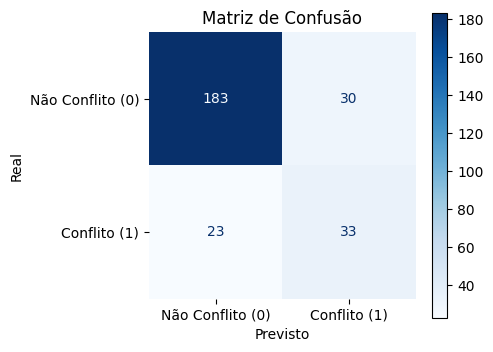

In [ ]:
#MATRIZ DE CONFUSÃO
#obtendo as classes previstas e reais
y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

# nomes das classes
labels = ["Não Conflito (0)", "Conflito (1)"]

# matriz
mat = confusion_matrix(y_true, y_pred)

# plot
fig, ax = plt.subplots(figsize=(5,4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=mat,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

# alterar nome dos eixos
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")

# remover bordas
for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(False)

plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()

# **Salvando o modelo**

In [ ]:
# Salvar modelo treinado
trainer.save_model("./modelo_conflito")

# Salvar tokenizer
tokenizer.save_pretrained("./modelo_conflito")

print("Modelo salvo com sucesso!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo salvo com sucesso!


In [ ]:
# Download do modelo
!zip -r modelo_conflito.zip modelo_conflito
files.download("modelo_conflito.zip")

# **Carregando o modelo**

In [ ]:
# baixando o modelo que foi feito o upload no drive: SE FOR TREINAR NOVAMENTE, COMENTAR ESTE TRECHO E O PROXIMO

file_id = "1ANtXli-9soQUXOj0WwZZNszTdXUxCR1Z"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url,"modelo_conflito.zip",quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1ANtXli-9soQUXOj0WwZZNszTdXUxCR1Z
From (redirected): https://drive.google.com/uc?id=1ANtXli-9soQUXOj0WwZZNszTdXUxCR1Z&confirm=t&uuid=6ba1aad8-9125-4876-98f6-6ec0b3a7df60
To: /content/modelo_conflito.zip
100%|██████████| 404M/404M [00:08<00:00, 45.9MB/s]


'modelo_conflito.zip'

In [ ]:
#descompactando
!unzip -q modelo_conflito.zip

In [ ]:
# Carregar tokenizer
tokenizer = BertTokenizer.from_pretrained("./modelo_conflito")

# Carregar modelo
model = BertForSequenceClassification.from_pretrained("./modelo_conflito")

# modo avaliação

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

# **Testando o modelo**

## **Função principal**

In [ ]:
def conflict_predict(texto1, texto2):
    # Tokenizar o texto recebido
    inputs = tokenizer(
        texto1,
        texto2,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    #realiza a predição
    with torch.no_grad(): # desliga o modo "aprendizado"

        outputs = model(**inputs) #chama o modelo com os textos tokenizados (inputs) "desempacotados". Output recebe um objeto retornado pelo modelo com os resultados

        probs = torch.softmax(outputs.logits, dim=1) #aplicamos softamx para obter as probabilidades

    prob_nao_conflito = probs[0][0].item() #pega a prob de nao conflito e ".item() transforma o objeto obtido (pytorch) em float "
    prob_conflito = probs[0][1].item() #pega a prob de nao conflito e ".item() transforma o objeto obtido (pytorch) em float "

    classe = int(torch.argmax(probs, dim=1)) #Com base nos logits, define a classse (0 ou 1)

    #Retornamos um dicionario com Classificação, prob_conflito, prob_nao_conflito
    return {
        "classificacao": classe,
        "prob_conflito": prob_conflito,
        "prob_nao_conflito": prob_nao_conflito
    }

## **TESTE INDIVIDUAL**

In [ ]:
#Teste individual
texto_1 = "Uai, eu também sou e pasme é #AbortoSim"
texto_2 = " Nem pessoas como vc merecia ser abortado. Defendo sempre a vida. #AbortoNAO"
resultado = conflict_predict(texto_1, texto_2)
print("PREDITOR DE CONFLITOS")
print(f"Texto 1: {texto_1}")
print(f"Texto 2: {texto_2}")
print(f"Probabilidade de não conflito: {resultado['prob_nao_conflito']}")
print(f"Probabilidade de conflito: {resultado['prob_conflito']}")
print(f"Classificação: {'NAO CONFLITO' if resultado['classificacao'] == 0 else 'CONFLITO'}")

PREDITOR DE CONFLITOS
Texto 1: Uai, eu também sou e pasme é #AbortoSim
Texto 2:  Nem pessoas como vc merecia ser abortado. Defendo sempre a vida. #AbortoNAO
Probabilidade de não conflito: 0.04448341950774193
Probabilidade de conflito: 0.9555165767669678
Classificação: CONFLITO


# **Teste em Datasets**

In [ ]:
# baixando dataset para o collab
file_id = "14Vjwm85CIT4xbJdpJEL6IUBnCHo0EaQR"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "dataset_nao_anotado.csv", quiet=False)

#carregando o dataset
df_full = pd.read_csv ("dataset_nao_anotado.csv")
df_full.shape

Downloading...
From: https://drive.google.com/uc?id=14Vjwm85CIT4xbJdpJEL6IUBnCHo0EaQR
To: /content/dataset_nao_anotado.csv
100%|██████████| 11.3M/11.3M [00:00<00:00, 138MB/s]


(44707, 3)

In [ ]:
# Dividindo o dataset em 3 partes:
df_genericos = df_full[df_full["Class"] == 0]
df_genericos = df_genericos.sample(frac=1, random_state=42).reset_index(drop=True)
df_reply = df_full[df_full["Class"] == 1]
df_reply = df_reply.sample(frac=1, random_state=42).reset_index(drop=True)
df_quotes = df_full[df_full["Class"] == 2]
df_quotes = df_quotes.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df_quotes.shape

(27900, 3)

In [ ]:
# Amostrando classes igualmente
df_genericos = df_genericos.loc[200:,:]
df_reply = df_reply.loc[200:,:]
df_quotes = df_quotes.loc[200:,:]

In [ ]:
df_teste = pd.concat([df_genericos, df_reply, df_quotes])
df_teste.shape

(44107, 3)

In [ ]:
df_teste = df_teste.sample(frac=1, random_state=42).reset_index(drop=True)
df_teste

,tweet_1,tweet_2,Class
0,Agora cada médico receita a cloroquina quando ...,Adoro Olavo!!,2
1,e a musica da cloroquina que ta na minha cabeç...,Então tem que ser responsabilizado pelo exercí...,0
2,Vocês concordam com a ampliação do uso da clor...,Uma grande ilustração de como argumento de aut...,0
3,pra quem ainda acha que medicos aprovam cloroq...,Será que vai ser preciso desenhar?!?!,2
4,"Bolsonaro quis alterar bula da cloroquina, diz...",Esse Presidente é mesmo uma aberração!!!,2
...,...,...,...
44102,"Cloroquina de Jesus , aplica logo, talkey?! #E...",Os robôs e o gado do bostanaro já entraram em ...,0
44103,O vem trabalhando em coordenação c/ o p/ tra...,"Não esqueçam, a cloroquina só é benéfica se fo...",1
44104,"Já que é pra polarizar, quem é de direita toma...",Exatamente #EuApoioBolsonaro,2
44105,"O medicamento pode causar: Distúrbio cardíaco,...",cLOROQUINA CLOROQUINHA,0


In [ ]:
# Função que aplica "conflict_detection" em lotes

def classificar_linha(row):

    resultado = conflict_predict(row["tweet_1"], row["tweet_2"])

    row["P(NoConflict)"] = resultado["prob_nao_conflito"]
    row["P(Conflict)"] = resultado["prob_conflito"]
    row["Conflict"] = resultado["classificacao"]

    return row

In [ ]:
# Chamando o classificador direto no dataset
df_teste = df_teste.apply(classificar_linha, axis=1)
df_teste

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Agora cada médico receita a cloroquina quando ...,Adoro Olavo!!,2,0.981465,0.018535,0
1,e a musica da cloroquina que ta na minha cabeç...,Então tem que ser responsabilizado pelo exercí...,0,0.944545,0.055455,0
2,Vocês concordam com a ampliação do uso da clor...,Uma grande ilustração de como argumento de aut...,0,0.098251,0.901749,1
3,pra quem ainda acha que medicos aprovam cloroq...,Será que vai ser preciso desenhar?!?!,2,0.947759,0.052241,0
4,"Bolsonaro quis alterar bula da cloroquina, diz...",Esse Presidente é mesmo uma aberração!!!,2,0.986598,0.013402,0
...,...,...,...,...,...,...
44102,"Cloroquina de Jesus , aplica logo, talkey?! #E...",Os robôs e o gado do bostanaro já entraram em ...,0,0.981521,0.018479,0
44103,O vem trabalhando em coordenação c/ o p/ tra...,"Não esqueçam, a cloroquina só é benéfica se fo...",1,0.985452,0.014548,0
44104,"Já que é pra polarizar, quem é de direita toma...",Exatamente #EuApoioBolsonaro,2,0.980505,0.019495,0
44105,"O medicamento pode causar: Distúrbio cardíaco,...",cLOROQUINA CLOROQUINHA,0,0.969559,0.030441,0


In [ ]:
#ordem decrescente de prob_conflito
df_ordenado_dec = df_teste.sort_values(by="P(Conflict)", ascending=False).reset_index(drop=True)
df_ordenado_dec

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Bolsonaro finalmente conseguiu forçar o Min. d...,"Vai comer o teu X tudo sua esquerdista, se tu ...",1,0.016883,0.983117,1
1,Bolsonaro finalmente conseguiu forçar o Min. d...,"Mas , vc não é obrigada a tomar. O nome disso ...",2,0.017871,0.982129,1
2,Bolsonaro finalmente conseguiu forçar o Min. d...,"Se vc pegar essa doença, tu enfia cloroquina a...",1,0.018332,0.981668,1
3,Bolsonaro finalmente conseguiu forçar o Min. d...,MESMO MALDITA ESQUERDALHA? ESPERO que vc não p...,2,0.018342,0.981658,1
4,Bolsonaro finalmente conseguiu forçar o Min. d...,"Fuma tua maconha, até pelo cu se quiser, q não...",1,0.018687,0.981313,1
...,...,...,...,...,...,...
44102,"Bolsonaro quis alterar bula da cloroquina, diz...",Bolsonaro ainda está tentando fazer a cloroqui...,2,0.995237,0.004762,0
44103,Meu corpo minhas regras Eu opto pela cloroquin...,#EuApoioBolsonaro #EuApoioBolsonaro #EuApoioBo...,2,0.995267,0.004733,0
44104,Hoje no Brasil: Covid-19 continua fazendo víti...,Cloroquina para o povão #EuApoioBolsonaro,0,0.995282,0.004718,0
44105,"Para a direita, cloroquina. Para a esquerda, t...",Hoje no Brasil: Covid-19 continua fazendo víti...,0,0.995335,0.004665,0


In [ ]:
#exibindo os resultados
for i in range(20):
  print("Tweet 1: ", df_ordenado_dec.loc[i,"tweet_1"])
  print("Tweet 2: ", df_ordenado_dec.loc[i,"tweet_2"])
  print("Probabilidade de nao conflito: ", df_ordenado_dec.loc[i,"P(NoConflict)"])
  print("Probabilidade de conflito: ", df_ordenado_dec.loc[i,"P(Conflict)"])
  print("Conflict: ", df_ordenado_dec.loc[i,"Conflict"])
  print()

Tweet 1:  Bolsonaro finalmente conseguiu forçar o Min. da Saúde a emitir protocolo que libera o uso em massa da cloroquina. Os pacientes terão que assinar um termo assumindo que o remédio não tem eficácia e que pode até matar. É um atentado contra a saúde pública e a vida dos brasileiros.
Tweet 2:  Vai comer o teu X tudo sua esquerdista, se tu pegar o vírus chinês, não vai tomar a cloroquina, vcs são uma desgraça para este país. E já vai levar block.
Probabilidade de nao conflito:  0.016883384436368942
Probabilidade de conflito:  0.983116626739502
Conflict:  1

Tweet 1:  Bolsonaro finalmente conseguiu forçar o Min. da Saúde a emitir protocolo que libera o uso em massa da cloroquina. Os pacientes terão que assinar um termo assumindo que o remédio não tem eficácia e que pode até matar. É um atentado contra a saúde pública e a vida dos brasileiros.
Tweet 2:  Mas , vc não é obrigada a tomar. O nome disso é liberdade. Sabe o que significa ou quer continuar enganando energúmenos?
Probabilida

In [ ]:
df_ordenado_dec["Conflict"] = np.nan
df_ordenado_dec

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Bolsonaro finalmente conseguiu forçar o Min. d...,"Vai comer o teu X tudo sua esquerdista, se tu ...",1,0.016883,0.983117,NaN
1,Bolsonaro finalmente conseguiu forçar o Min. d...,"Mas , vc não é obrigada a tomar. O nome disso ...",2,0.017871,0.982129,NaN
2,Bolsonaro finalmente conseguiu forçar o Min. d...,"Se vc pegar essa doença, tu enfia cloroquina a...",1,0.018332,0.981668,NaN
3,Bolsonaro finalmente conseguiu forçar o Min. d...,MESMO MALDITA ESQUERDALHA? ESPERO que vc não p...,2,0.018342,0.981658,NaN
4,Bolsonaro finalmente conseguiu forçar o Min. d...,"Fuma tua maconha, até pelo cu se quiser, q não...",1,0.018687,0.981313,NaN
...,...,...,...,...,...,...
44102,"Bolsonaro quis alterar bula da cloroquina, diz...",Bolsonaro ainda está tentando fazer a cloroqui...,2,0.995237,0.004762,NaN
44103,Meu corpo minhas regras Eu opto pela cloroquin...,#EuApoioBolsonaro #EuApoioBolsonaro #EuApoioBo...,2,0.995267,0.004733,NaN
44104,Hoje no Brasil: Covid-19 continua fazendo víti...,Cloroquina para o povão #EuApoioBolsonaro,0,0.995282,0.004718,NaN
44105,"Para a direita, cloroquina. Para a esquerda, t...",Hoje no Brasil: Covid-19 continua fazendo víti...,0,0.995335,0.004665,NaN


In [ ]:
df_ordenado_dec.to_csv("cloroquina_anotar.csv", index=False, encoding="utf-8")
files.download("cloroquina_anotar.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>